In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv('blinkit_multiclass.csv')

In [4]:
df

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1
...,...,...,...,...,...,...,...,...
435,3,29703,12051,16027,13135,182,2204,2
436,3,39228,1431,764,4510,93,2346,2
437,3,14531,15488,30243,437,14841,1867,2
438,3,10290,1981,2232,1038,168,2125,3


In [5]:
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']].copy()
X

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3,12669,9656,7561,214,2674,1338
1,3,7057,9810,9568,1762,3293,1776
2,3,6353,8808,7684,2405,3516,7844
3,3,13265,1196,4221,6404,507,1788
4,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...
435,3,29703,12051,16027,13135,182,2204
436,3,39228,1431,764,4510,93,2346
437,3,14531,15488,30243,437,14841,1867
438,3,10290,1981,2232,1038,168,2125


In [6]:
Y=df[['class']].copy()
Y

,class
0,2
1,2
2,2
3,1
4,1
...,...
435,2
436,2
437,2
438,3


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 

print("Before PCA:",X.shape)

pca=PCA(n_components=2)
X=pca.fit_transform(X)
print("After PCA:",X.shape)

Before PCA: (440, 7)
After PCA: (440, 2)


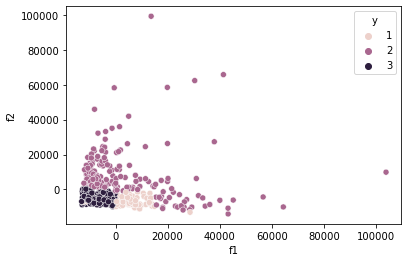

In [8]:
df2=pd.DataFrame(X, columns=['f1','f2'])
df2['y']=Y

sns.scatterplot(data=df2, x='f1',y='f2', hue='y')
plt.show()

In [9]:
print("X shape:", X.shape)
print("Y shape:",Y.shape)

X shape: (440, 2)
Y shape: (440, 1)


In [10]:
Y.values[:,0]

array([2, 2, 2, 1, 1, 3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 3, 1, 3,
       2, 2, 2, 2, 3, 1, 2, 2, 2, 3, 1, 2, 3, 2, 2, 2, 2, 2, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 1, 3, 2, 2, 1, 3, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 3, 1, 2, 3, 1, 2, 1, 3, 2, 3, 3, 3, 2, 2, 1, 3, 2, 2, 2,
       3, 1, 3, 1, 2, 1, 2, 3, 3, 3, 3, 3, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2,
       3, 2, 1, 1, 1, 3, 3, 3, 1, 3, 1, 3, 3, 2, 2, 2, 1, 2, 3, 2, 3, 3,
       1, 3, 3, 3, 2, 2, 1, 3, 1, 2, 2, 3, 1, 2, 3, 3, 3, 2, 1, 3, 1, 3,
       3, 2, 2, 1, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 1, 3, 2, 2, 3, 2, 3, 2,
       2, 1, 3, 3, 2, 2, 2, 2, 3, 3, 1, 2, 2, 2, 1, 1, 3, 2, 3, 1, 2, 2,
       3, 3, 2, 2, 2, 3, 3, 2, 1, 3, 3, 2, 1, 2, 3, 3, 2, 2, 2, 1, 2, 3,
       1, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 1, 3, 3, 1, 3, 2, 1, 1,
       1, 3, 2, 2, 3, 1, 1, 3, 3, 2, 3, 2, 2, 2, 3, 3, 2, 2, 3, 3, 1, 3,
       2, 2, 2, 1, 2, 1, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 2, 2, 1, 2, 2,
       3, 1, 1, 1, 3, 3, 3, 2, 1, 3, 1, 3, 2, 3, 1,

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X,Y.values[:,0],test_size=0.25,random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.25,random_state=42)


In [12]:
print("X-train:",X_train.shape,"Y-train",y_train.shape)
print("X-val:",X_val.shape,"Y-val",y_val.shape)
print("X-test:",X_test.shape,"Y-test",y_test.shape)

X-train: (247, 2) Y-train (247,)
X-val: (83, 2) Y-val (83,)
X-test: (110, 2) Y-test (110,)


# Implementation from scratch

In [13]:
# Standization
mu=X_train.mean(axis=0)
sig=X_train.std(axis=0)

In [14]:
X_train = (X_train-mu)/sig
X_val = (X_val-mu)/sig
X_test = (X_test-mu)/sig

In [15]:
print("X-train:",X_train.shape,"Y-train",y_train.shape)
print("X-val:",X_val.shape,"Y-val",y_val.shape)
print("X-test:",X_test.shape,"Y-test",y_test.shape)

X-train: (247, 2) Y-train (247,)
X-val: (83, 2) Y-val (83,)
X-test: (110, 2) Y-test (110,)


In [16]:
data1=[[10,100],[20,200],[30,300],[40,400]]
data2=[[5,10],[10,20],[30,40],[50,60]]
x=[2,5]

df1=pd.DataFrame(data1, columns=['col1','col2'])
df2=pd.DataFrame(data2, columns=['col1','col2'])

In [17]:
df1

,col1,col2
0,10,100
1,20,200
2,30,300
3,40,400


In [18]:
df2

,col1,col2
0,5,10
1,10,20
2,30,40
3,50,60


In [19]:
np.sum(df1-df2, axis=1)

0     95
1    190
2    260
3    330
dtype: int64

In [20]:
np.sum(df1-df2, axis=0)

col1      5
col2    870
dtype: int64

In [21]:
np.sum(df1-x, axis=1)

0    103
1    213
2    323
3    433
dtype: int64

In [22]:
dist=np.sqrt(np.sum((X[30]-X_train)**2,axis=1))
print("Shape:",dist.shape)
print(len(dist))

distances = [(dist[i], y_train[i]) for i in range(0,len(dist)) ]
print(np.shape(distances))

Shape: (247,)
247
(247, 2)


In [23]:
for i in range(0,len(dist)):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246


In [24]:
def knn(x,y,queryPoint, k=5):
    #Euclidean distance
    dist=np.sqrt(np.sum((queryPoint-x)**2,axis=1))
    #print("X:",np.shape(x))
    #print("Y:",np.shape(y))
    #print("Distance:",np.shape(dist))
    
    # Storing distance and class label together
    distances = [(dist[i], y[i]) for i in range(len(dist)) ]
    
    #print("XXXXXXXXXXXXXXXXXX")
    #print("Distance:",distances)
    #Sort distances
    distances=sorted(distances,key=lambda x: x[0])
    
    #Nearest k-points
    distances=distances[:k]
    
    distances=np.array(distances)
    
    class_counts=np.unique(distances[:,1], return_counts= True)
    
    index=class_counts[1].argmax()
    pred=class_counts[0][index]
    
    return int(pred)

In [25]:
print(X_test[50])

[0.12263833 1.24645031]


In [26]:
print(y_test[50])

2


In [27]:
print(knn(X_train,y_train,X_test[50]))

2


In [38]:
def knn_predict(X_train,Y_train,X_test,y_test):
    
    y_pred = np.zeros(X_test.shape[0])
    
    for i in range(0,X_test.shape[0]):
        y_pred[i]=knn(X_train,Y_train,X_test[i])
    
    print(f'Accuracy: ', round(100*(y_pred==y_test.astype(int)).sum()/y_pred.shape[0],2))

In [39]:
knn_predict(X_train,y_train,X_test,y_test)

Accuracy:  95.45


In [44]:
# Hyper parameter tuning
def give_me_accuracy(k):
    y_pred=[]
    
    for Xq in X_test:
        pred=knn(X_train,y_train,Xq,k=k)
        y_pred.append(pred)
        
    y_pred=np.array(y_pred)
    acc=round(100*(y_pred==y_test.astype(int)).sum()/len(y_test),2)
    return acc

In [45]:
scores = []
k_values = []


for k in range(1, 15):
    k_values.append(k)
    score = give_me_accuracy(k)
    scores.append(score)

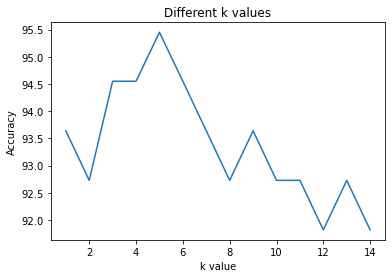

In [46]:
plt.plot(k_values, scores)
plt.title("Different k values")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.show()

In [47]:
print(np.argmax(scores))
print("Best k is", k_values[np.argmax(scores)])

4
best k is 5


# Implementation using sklearn

In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [49]:
y_pred = knn.predict(X_test)
knn.score(X_test, y_test)

0.9545454545454546

In [54]:
x_q = [X_test[26]]
y_q = y_test[26]
print("Xq: ",x_q)
print("Yq: ", y_q)
print("Predictions: ", knn.predict(x_q))
print(knn.predict_proba(x_q))
print(knn.kneighbors(x_q))

Xq:  [array([ 0.42014925, -0.62637863])]
Yq:  1
Predictions:  [1]
[[1. 0. 0.]]
(array([[0.03060139, 0.04304506, 0.07119543, 0.0718539 , 0.07810146]]), array([[ 60,  94, 229, 164, 190]], dtype=int64))


In [55]:
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(classification_report(y_test, y_pred))
plt.show()

              precision    recall  f1-score   support

           1       0.90      0.90      0.90        20
           2       0.98      0.94      0.96        47
           3       0.96      1.00      0.98        43

    accuracy                           0.95       110
   macro avg       0.94      0.95      0.94       110
weighted avg       0.95      0.95      0.95       110

